# Phase 3 — Training/Eval Harness

Goal: a training loop, checkpointing, TensorBoard + CSV logging, and evaluation
(accuracy, macro-F1, per-class recall, confusion matrix) -- built once here and
reused **unmodified** through Phases 4-7, so the Phase 8 comparison across the
from-scratch CNN and the three transfer-learning variants is apples-to-apples.

This notebook validates the harness end-to-end using a **throwaway tiny model on a
small data subset** -- fast enough to run locally on CPU. The real architecture work
is Phase 4's job, not this notebook's. Every piece exercised here (`src/training/`)
is exactly what Phase 4 will call, just with a real model and the full dataset.

In [12]:
# Colab only: mount Drive and cd into the synced project folder.
# Safe to run locally too -- the import fails there and this cell is skipped.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "/content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project"
except ImportError:
    pass

In [13]:
import sys, os

# Walk up from cwd to the project root (marked by configs/config.yaml) and put it on
# sys.path. Plain os.getcwd() isn't reliable here -- it depends on how the kernel was
# launched (VS Code's Jupyter extension defaults to the notebook's own folder, not the
# project root, which differs from how this ran on Linux before).
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "configs", "config.yaml")):
    _parent = os.path.dirname(_root)
    if _parent == _root:
        raise RuntimeError("Could not find project root (configs/config.yaml) above " + os.getcwd())
    _root = _parent
sys.path.append(_root)

import random
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn

from src.utils.config import load_config
from src.utils.seed import seed_everything
from src.utils.device import get_device
from src.data import splits, transforms as T, dataset as D
from src.data.fetch_data import fetch_dataset
from src.training.trainer import train_model
from src.training.checkpoint import load_checkpoint
from src.training import engine
from src.training.metrics import plot_confusion_matrix

cfg = load_config()
seed_everything(cfg["seed"])
device = get_device(cfg["training"]["device"])
print("Environment:", cfg["env"], "| Device:", device)

fetch_dataset(cfg)  # no-op if already downloaded

Environment: local | Device: cpu
Dataset already present at D:\Diljith_A_K\dataset\PlantVillage\color (38 class folders). Skipping download.


WindowsPath('D:/Diljith_A_K/dataset/PlantVillage/color')

## 1. Load Phase 2's fixed split

In [14]:
ARTIFACTS_DIR = cfg["data"]["artifacts_dir"]
splits_path = Path(ARTIFACTS_DIR) / "splits.csv"
class_to_idx_path = Path(ARTIFACTS_DIR) / "class_to_idx.json"

if not splits_path.exists() or not class_to_idx_path.exists():
    raise FileNotFoundError(
        f"{splits_path} or {class_to_idx_path} missing -- run notebooks/02_data_pipeline.ipynb first."
    )

splits_df = pd.read_csv(splits_path)
class_to_idx = splits.build_class_to_idx(cfg["data"]["path"], cache_path=str(class_to_idx_path))
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"Loaded split: {len(splits_df)} images, {num_classes} classes")

Loaded split: 54305 images, 38 classes


## 2. A small subset, for a fast smoke test

5 train + 2 val images per class (of the already-fixed split -- this doesn't touch
`splits.csv`, just samples from it) so the whole harness can be exercised quickly on
CPU. Phase 4 uses the full split.

In [15]:
subset_rows = []
for cls, group in splits_df.groupby("class"):
    train_rows = group[group["split"] == "train"].sample(
        n=min(5, (group["split"] == "train").sum()), random_state=cfg["seed"]
    )
    val_rows = group[group["split"] == "val"].sample(
        n=min(2, (group["split"] == "val").sum()), random_state=cfg["seed"]
    )
    subset_rows += [train_rows, val_rows]

subset_df = pd.concat(subset_rows).reset_index(drop=True)
print("Subset size:", len(subset_df), dict(subset_df["split"].value_counts()))

Subset size: 266 {'train': np.int64(190), 'val': np.int64(76)}


In [ ]:
train_transform = T.get_train_transforms(cfg)
eval_transform = T.get_eval_transforms(cfg)

loaders = D.make_dataloaders(
    subset_df, class_to_idx, train_transform, eval_transform, batch_size=8, num_workers=0,
    data_path=cfg["data"]["path"],
)
print({k: len(v.dataset) for k, v in loaders.items()})

## 3. A throwaway model -- validates the harness only

Not the Phase 4 deliverable. The real from-scratch CNN, with deliberate architecture
choices to learn from, is built and iterated on in `notebooks/04_cnn_from_scratch.ipynb`.

In [17]:
class DummyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(4),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(16, num_classes)

    def forward(self, x):
        x = self.features(x)
        return self.fc(x.flatten(1))


model = DummyCNN(num_classes)
sum(p.numel() for p in model.parameters())

2038

## 4. Train

Class-weighted loss, using Phase 2's `compute_class_weights` (computed from the train
split, here applied to the subset). `make_weighted_sampler` is also available in
`src/data/dataset.py` as the alternative mechanism -- Phase 4 decides which (or both)
actually helps minority-class recall on the full dataset.

In [18]:
class_weights = D.compute_class_weights(subset_df[subset_df["split"] == "train"], class_to_idx).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_model(
    model, loaders, criterion, optimizer, device,
    run_name="phase3_smoketest", cfg=cfg, class_to_idx=class_to_idx, max_epochs=2,
)
pd.DataFrame(history)

train:   0%|          | 0/24 [00:00<?, ?it/s]d:\Diljith_A_K\.venvs\plant_disease\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 0: train_loss=3.6601 val_loss=3.6448 val_acc=0.0263 val_macro_f1=0.0014 (2.0s)


train:   0%|          | 0/24 [00:00<?, ?it/s]d:\Diljith_A_K\.venvs\plant_disease\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                      

Epoch 1: train_loss=3.6445 val_loss=3.6415 val_acc=0.0000 val_macro_f1=0.0000 (1.9s)


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,lr,epoch_time_sec
0,0,3.660059,3.644753,0.026316,0.001404,0.001,2.017176
1,1,3.644465,3.641519,0.000000,0.000000,0.001,1.914106


## 5. Verify checkpoints, logs, and a checkpoint round-trip

Not just "the code ran" -- confirm the saved checkpoint reloads into a **fresh** model
instance and reproduces the exact metrics it was saved with.

In [19]:
checkpoints_dir = Path(cfg["logging"]["checkpoints_dir"]) / "phase3_smoketest"
best_path = checkpoints_dir / "best.pt"
last_path = checkpoints_dir / "last.pt"
assert best_path.exists() and last_path.exists()
print("Checkpoints:", list(checkpoints_dir.iterdir()))

fresh_model = DummyCNN(num_classes).to(device)
payload = load_checkpoint(best_path, fresh_model, optimizer=None, map_location=device)
assert payload["class_to_idx"] == class_to_idx, "class_to_idx did not round-trip!"
print(f"Reloaded checkpoint from epoch {payload['epoch']}, best_metric={payload['best_metric']:.4f}")

reloaded_metrics = engine.evaluate(fresh_model, loaders["val"], criterion, device, num_classes)
logged_metric = next(h["val_macro_f1"] for h in history if h["epoch"] == payload["epoch"])
print(f"Reloaded val_macro_f1: {reloaded_metrics['macro_f1']:.6f} | Logged at train time: {logged_metric:.6f}")
assert abs(reloaded_metrics["macro_f1"] - logged_metric) < 1e-6, "checkpoint round-trip mismatch!"
print("Round-trip OK -- reloaded model reproduces the exact logged metric.")

Checkpoints: [WindowsPath('G:/My Drive/Colab Notebooks/Plant_Disease_Classification_Project/experiments/checkpoints/phase3_smoketest/best.pt'), WindowsPath('G:/My Drive/Colab Notebooks/Plant_Disease_Classification_Project/experiments/checkpoints/phase3_smoketest/last.pt')]
Reloaded checkpoint from epoch 0, best_metric=0.0014


eval:   0%|          | 0/10 [00:00<?, ?it/s]d:\Diljith_A_K\.venvs\plant_disease\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                            

Reloaded val_macro_f1: 0.001404 | Logged at train time: 0.001404
Round-trip OK -- reloaded model reproduces the exact logged metric.


In [20]:
run_dir = Path(cfg["logging"]["logs_dir"]) / "phase3_smoketest"
csv_log = pd.read_csv(run_dir / "metrics.csv")
tb_files = list(run_dir.glob("events.out.tfevents.*"))

print("CSV log:")
print(csv_log)
print(f"\nTensorBoard event files: {len(tb_files)}")

CSV log:
   epoch  train_loss  val_loss  val_accuracy  val_macro_f1     lr  \
0      0    3.660059  3.644753      0.026316      0.001404  0.001   
1      1    3.644465  3.641519      0.000000      0.000000  0.001   

   epoch_time_sec  
0        2.017176  
1        1.914106  

TensorBoard event files: 1


## 6. Confusion matrix plotting utility

Mostly empty here (tiny subset, 2 epochs, throwaway model) -- the point is to confirm
`plot_confusion_matrix` runs correctly against real metrics output. This is what
Phase 8 will use for real, on the full test set.

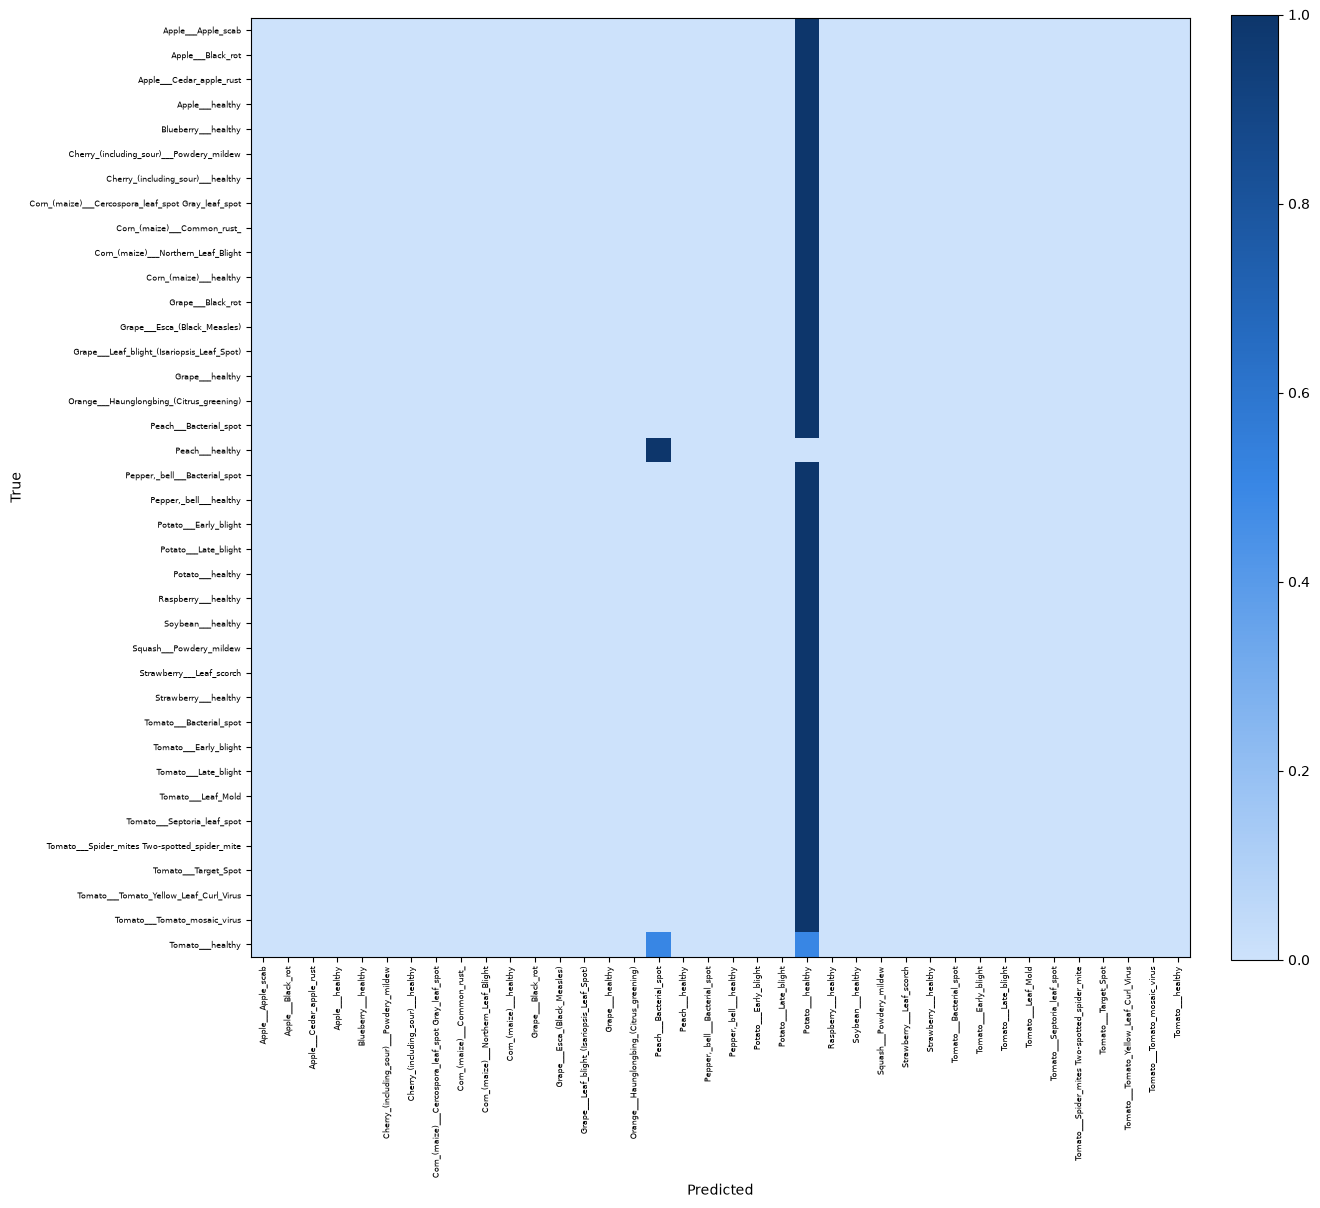

In [21]:
class_names = [idx_to_class[i] for i in range(num_classes)]
plot_confusion_matrix(reloaded_metrics["confusion_matrix"], class_names)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

## Summary & implications for Phase 4

In [22]:
print("Harness pieces validated:")
print("- train_model() (src/training/trainer.py): training loop, early stopping, checkpointing")
print("- engine.train_one_epoch / engine.evaluate: model-agnostic, works with any nn.Module")
print("- compute_metrics: accuracy, macro_f1, per_class_recall, confusion_matrix -- all with correct shape even on a tiny subset")
print("- RunLogger: TensorBoard + incrementally-appended CSV")
print("- checkpoint save/load: round-trip verified exact")
print("- make_weighted_sampler (src/data/dataset.py): available, not yet exercised in training -- Phase 4 decision")

Harness pieces validated:
- train_model() (src/training/trainer.py): training loop, early stopping, checkpointing
- engine.train_one_epoch / engine.evaluate: model-agnostic, works with any nn.Module
- compute_metrics: accuracy, macro_f1, per_class_recall, confusion_matrix -- all with correct shape even on a tiny subset
- RunLogger: TensorBoard + incrementally-appended CSV
- checkpoint save/load: round-trip verified exact
- make_weighted_sampler (src/data/dataset.py): available, not yet exercised in training -- Phase 4 decision


Takeaways to carry into Phase 4:

- **The harness is done and does not need to change** for the from-scratch CNN, or
  for any of the Phases 5-7 transfer-learning variants. Phase 4 imports
  `train_model` and `engine.evaluate` directly rather than writing a new loop.
- **`checkpoint_metric` is `macro_f1`**, not accuracy (see `configs/config.yaml`) --
  a model that just predicts the majority class will not look good by this harness's
  own bookkeeping, which is the point given the 36x imbalance.
- **The imbalance-handling decision is still open**: weighted loss (used above) vs.
  `make_weighted_sampler` vs. both. Phase 4 should try the from-scratch CNN with and
  without weighting and look at per-class recall, not just aggregate accuracy, before
  deciding.
- Checkpoints carry `class_to_idx` -- Phase 8 can load any of the four run's
  checkpoints without re-deriving which index means which class.